In [1]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import spearmanr

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [3]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

# regions_of_interest = ['ENSG00000131471', 'ENSG00000084674']
regions_of_interest = ['ENSG00000131471']

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(regions_of_interest)),

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .unique()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


esmscoremissense,relative_cds_position,consequence_start_lost,mobi_curated_disorder_priority,aparent2,cadd_raw,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,esm1b_llr,region,consequence_missense_variant,id,am_pathogenicity,absplice2_max,delta_score,consequence_frameshift_variant,cpt1_llr,five_prime_utr_variant_consequence_uaug_lost,abexp_min,clinpred_score,low_complexity_domain,five_prime_utr_variant_consequence_ustop_lost,encode_tf,encode_dels,consequence_splice_acceptor_variant,gpn_score,pangolin_score,ted_domain,consequence_stop_gained,consequence_synonymous_variant,encode_pls,consequence_splice_donor_variant,consequence_stop_lost,five_prime_utr_variant_consequence_ustop_gained,encode_pels,verphylop,abexp_abs_max,bayes_del,loftee_lc,polyphen,revel_score
f32,f32,i8,bool,f32,f32,i8,u8,f32,str,i8,str,f32,f32,f32,i8,f32,u8,f32,f32,bool,u8,bool,bool,i8,f32,f32,bool,i8,i8,bool,i8,i8,u8,bool,f32,f32,f32,i8,f32,f32
0.0,0.0,0,false,0.0,-0.180518,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42848559:A:ATG""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,true,0,-1.41,0.0,false,0,0,false,0,0,0,false,0.129,0.0,-0.249576,0,0.0,0.0
0.0,0.0,0,false,0.0,0.107108,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42848112:G:A""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,1.94,0.0,false,0,0,false,0,0,0,false,-0.614,0.002469,-0.249576,0,0.0,0.0
0.0,0.0,0,false,0.0,0.154456,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42862497:T:C""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,0.43,0.0,false,0,0,false,0,0,0,false,-1.025,0.0,-0.249576,0,0.0,0.0
0.0,0.0,0,false,0.0,0.036434,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42851028:C:T""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,-0.03,0.0,false,0,0,true,0,0,0,false,-0.805,0.002469,-0.249576,0,0.0,0.0
0.0,0.0,0,false,0.0,0.388012,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42846778:G:T""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,true,0,-1.57,0.0,false,0,0,false,0,0,0,false,1.361,0.002372,-0.249576,0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0,false,0.0,1.201851,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42855850:T:C""",0.0,0.000034,0.02,0,0.0,0,-0.012736,0.0,false,0,false,false,0,-1.37,0.01,false,0,0,false,0,0,0,false,0.015,0.012736,-0.249576,0,0.0,0.0
-6.189,0.34,0,false,0.0,3.687469,0,0,-8.692,"""ENSG00000131471""",1,"""chr17:42852115:C:T""",0.0935,0.000033,0.0,0,0.305673,0,-0.015385,0.654309,false,0,false,false,0,-3.88,0.0,true,0,0,false,0,0,0,true,0.388,0.015385,-0.643925,0,0.99,0.106
0.0,0.0,0,false,0.0,-0.653418,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42861898:CT:C""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,-1.41,0.0,false,0,0,false,0,0,0,false,0.129,0.0,-0.249576,0,0.0,0.0


# Olink scatter plot

In [4]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"
APPV_FILE = "olink_protrider_t_df_loftee_mac20_EURunrelated_appv_percentiles_small_desc.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

olink_appv

Error: path "/home/dnanexus/olink_protrider_t_df_loftee_mac20_EURunrelated_app
v_percentiles_small_desc.parquet" already exists but -f/--overwrite was not
set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr17:42847512:G:A""","""ENSG00000131471_olink""",0.647733,1
"""chr17:42854956:C:T""","""ENSG00000131471_olink""",0.14298,1
"""chr17:42848897:C:G""","""ENSG00000131471_olink""",-0.639064,2
"""chr17:42848090:T:TTTA""","""ENSG00000131471_olink""",-0.595697,2
"""chr17:42859525:C:T""","""ENSG00000131471_olink""",0.692828,1
…,…,…,…
"""chr17:42852113:C:T""","""ENSG00000131471_olink""",-0.652947,1
"""chr17:42846621:C:T""","""ENSG00000131471_olink""",1.215292,1
"""chr17:42856030:T:TGTC""","""ENSG00000131471_olink""",-0.740016,1


In [5]:
olink_plot_df = (
    anno
    .join(
        olink_appv, on='id', how='inner'
    )
)

olink_plot_df

esmscoremissense,relative_cds_position,consequence_start_lost,mobi_curated_disorder_priority,aparent2,cadd_raw,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,esm1b_llr,region,consequence_missense_variant,id,am_pathogenicity,absplice2_max,delta_score,consequence_frameshift_variant,cpt1_llr,five_prime_utr_variant_consequence_uaug_lost,abexp_min,clinpred_score,low_complexity_domain,five_prime_utr_variant_consequence_ustop_lost,encode_tf,encode_dels,consequence_splice_acceptor_variant,gpn_score,pangolin_score,ted_domain,consequence_stop_gained,consequence_synonymous_variant,encode_pls,consequence_splice_donor_variant,consequence_stop_lost,five_prime_utr_variant_consequence_ustop_gained,encode_pels,verphylop,abexp_abs_max,bayes_del,loftee_lc,polyphen,revel_score,phenotype,mean_pheno_value,n_individuals
f32,f32,i8,bool,f32,f32,i8,u8,f32,str,i8,str,f32,f32,f32,i8,f32,u8,f32,f32,bool,u8,bool,bool,i8,f32,f32,bool,i8,i8,bool,i8,i8,u8,bool,f32,f32,f32,i8,f32,f32,str,f32,i32
0.0,0.0,0,false,0.0,0.107108,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42848112:G:A""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,1.94,0.0,false,0,0,false,0,0,0,false,-0.614,0.002469,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",0.738398,1
0.0,0.0,0,false,0.0,0.319636,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42861907:T:C""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,-0.35,0.0,false,0,0,false,0,0,0,false,0.203,0.0,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",1.059271,1
0.0,0.0,0,false,0.0,-0.235739,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42849950:C:T""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,-1.31,0.0,false,0,0,false,0,0,0,true,-0.457,0.002469,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",0.364955,1
0.0,0.0,0,false,0.0,0.177897,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42853308:T:G""",0.0,0.00079,0.0,0,0.0,0,-0.069858,0.0,false,0,false,false,0,-1.5,0.0,false,0,0,true,0,0,0,false,-0.31,0.069858,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",0.433023,2
0.0,0.0,0,false,0.0,0.28051,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42862782:GT:G""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,-1.41,0.0,false,0,0,false,0,0,0,false,0.129,0.0,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",0.631655,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,0,false,0.0,0.286884,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42857655:T:C""",0.0,0.000033,0.0,0,0.0,0,-0.006087,0.0,false,0,false,true,0,-1.62,0.0,false,0,0,false,0,0,0,false,1.096,0.006087,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",-0.171089,2
-6.86,0.52,0,false,0.0,3.135483,0,0,-7.409,"""ENSG00000131471""",1,"""chr17:42852530:C:T""",0.0891,0.000142,0.0,0,0.22554,0,-0.079895,0.692828,false,0,false,false,0,-1.99,0.0,false,0,0,false,0,0,0,true,0.474,0.079895,-0.577758,0,0.878,0.081,"""ENSG00000131471_olink""",-2.666385,2
0.0,0.0,0,false,0.0,0.162722,0,0,0.0,"""ENSG00000131471""",0,"""chr17:42859869:G:T""",0.0,0.0,0.0,0,0.0,0,0.0,0.0,false,0,false,false,0,-1.15,0.0,false,0,0,false,0,0,0,false,0.621,0.0,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",0.373775,1


In [6]:
# Select annotation to plot
selected_annotation = 'am_pathogenicity'

# Look up color and label from config
_anno_row = anno_config_df.filter(pl.col('annotation') == selected_annotation)
anno_color = _anno_row['color'][0]
anno_label = _anno_row['label'][0]

print(f"Annotation: {selected_annotation} → {anno_label} (color: {anno_color})")

Annotation: am_pathogenicity → AlphaMissense (color: #feb72d)


In [10]:
olink_plot_df.filter(pl.col(selected_annotation) != 0)

esmscoremissense,relative_cds_position,consequence_start_lost,mobi_curated_disorder_priority,aparent2,cadd_raw,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,esm1b_llr,region,consequence_missense_variant,id,am_pathogenicity,absplice2_max,delta_score,consequence_frameshift_variant,cpt1_llr,five_prime_utr_variant_consequence_uaug_lost,abexp_min,clinpred_score,low_complexity_domain,five_prime_utr_variant_consequence_ustop_lost,encode_tf,encode_dels,consequence_splice_acceptor_variant,gpn_score,pangolin_score,ted_domain,consequence_stop_gained,consequence_synonymous_variant,encode_pls,consequence_splice_donor_variant,consequence_stop_lost,five_prime_utr_variant_consequence_ustop_gained,encode_pels,verphylop,abexp_abs_max,bayes_del,loftee_lc,polyphen,revel_score,phenotype,mean_pheno_value,n_individuals
f32,f32,i8,bool,f32,f32,i8,u8,f32,str,i8,str,f32,f32,f32,i8,f32,u8,f32,f32,bool,u8,bool,bool,i8,f32,f32,bool,i8,i8,bool,i8,i8,u8,bool,f32,f32,f32,i8,f32,f32,str,f32,i32
-4.144,0.28,0,false,0.0,3.018591,0,0,-5.459,"""ENSG00000131471""",1,"""chr17:42851981:C:T""",0.1253,0.000034,0.0,0,0.411298,0,-0.015385,0.137872,false,0,false,false,0,-2.25,0.01,true,0,0,false,0,0,0,true,1.242,0.015385,-0.530206,0,0.916,0.109,"""ENSG00000131471_olink""",-0.483448,2
-3.49,0.13,0,false,0.0,4.322865,0,0,-8.525,"""ENSG00000131471""",1,"""chr17:42851639:T:C""",0.2951,0.00011,0.0,0,0.430632,0,-0.118123,0.97239,false,0,false,false,0,-8.49,0.0,true,0,0,false,0,0,0,false,6.978,0.118123,-0.315944,0,0.999,0.331,"""ENSG00000131471_olink""",-1.842758,1
-7.409,0.96,0,false,0.0,3.810387,0,0,-9.469,"""ENSG00000131471""",1,"""chr17:42856465:T:G""",0.1009,0.000033,0.0,0,0.446366,0,-0.015428,0.6973,false,0,false,false,0,-6.88,0.0,false,0,0,false,0,0,0,false,0.169,0.015428,-0.587849,0,0.606,0.079,"""ENSG00000131471_olink""",-1.993302,1
-2.67,0.26,0,false,0.0,2.10084,0,0,-3.161,"""ENSG00000131471""",1,"""chr17:42851930:A:G""",0.068,0.000033,0.0,0,0.066314,0,-0.012423,0.097827,false,0,false,false,0,-4.99,0.0,true,0,0,false,0,0,0,true,0.278,0.012423,-0.482714,0,0.037,0.103,"""ENSG00000131471_olink""",0.011048,1
-4.277,0.2,0,false,0.0,3.713425,0,0,-8.291,"""ENSG00000131471""",1,"""chr17:42851800:C:T""",0.1286,0.000223,0.0,0,0.339982,0,-0.100185,0.974585,false,0,false,false,0,-5.38,0.01,true,0,0,false,0,0,0,false,0.299,0.100185,-0.432464,0,0.872,0.203,"""ENSG00000131471_olink""",-2.077949,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
-7.913,0.56,0,false,0.0,3.560879,0,0,-9.141,"""ENSG00000131471""",1,"""chr17:42852626:C:G""",0.1596,0.000033,0.0,0,0.338118,0,-0.015699,0.799319,false,0,false,false,0,-6.26,0.0,false,0,0,false,0,0,0,true,3.754,0.015699,-0.467172,0,0.096,0.163,"""ENSG00000131471_olink""",-3.350783,1
-4.328,0.07,0,false,0.0,1.002674,0,0,-9.985,"""ENSG00000131471""",1,"""chr17:42851503:C:G""",0.0625,0.000138,0.01,0,0.151301,0,-0.002192,0.063456,false,0,false,false,0,-3.24,0.01,false,0,0,false,0,0,0,false,0.099,0.002667,-0.67889,0,0.005,0.105,"""ENSG00000131471_olink""",0.45427,1
-8.021,0.78,0,false,0.0,4.078639,0,0,-6.76,"""ENSG00000131471""",1,"""chr17:42854631:A:G""",0.1629,0.000412,0.0,0,0.410504,0,-0.083404,0.99467,false,0,false,false,0,-7.34,0.0,true,0,0,false,0,0,0,true,7.011,0.083404,-0.471512,0,0.714,0.298,"""ENSG00000131471_olink""",-1.854371,1


Spearman ρ = -0.308 (p = 1.23e-24)


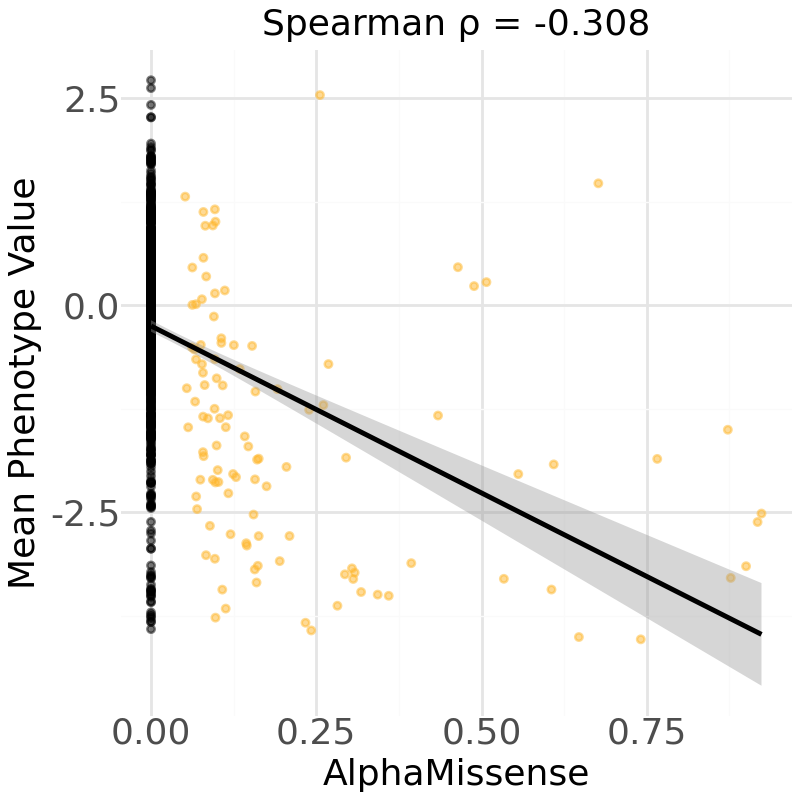

In [7]:
scatter_df = (
    olink_plot_df
    .select(['id', selected_annotation, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        is_scored = pl.when(pl.col(selected_annotation) != 0)
            .then(pl.lit('Scored'))
            .otherwise(pl.lit('Not scored'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    scatter_df[selected_annotation].to_numpy(),
    scatter_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(scatter_df, aes(y='mean_pheno_value', x=selected_annotation))
    + geom_point(aes(color='is_scored'), alpha=0.5, size=1)
    + scale_color_manual(
        values={'Scored': anno_color, 'Not scored': 'black'},
    )
    + geom_smooth(method='glm', color='black', se=True)
    + labs(
        x=anno_label,
        y='Mean Phenotype Value',
        title=f'Spearman ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(4, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
        legend_position='none',
    )
)

In [11]:
olink_plot_df.filter(pl.col('loftee_hc') != 0)

esmscoremissense,relative_cds_position,consequence_start_lost,mobi_curated_disorder_priority,aparent2,cadd_raw,loftee_hc,five_prime_utr_variant_consequence_uaug_gained,esm1b_llr,region,consequence_missense_variant,id,am_pathogenicity,absplice2_max,delta_score,consequence_frameshift_variant,cpt1_llr,five_prime_utr_variant_consequence_uaug_lost,abexp_min,clinpred_score,low_complexity_domain,five_prime_utr_variant_consequence_ustop_lost,encode_tf,encode_dels,consequence_splice_acceptor_variant,gpn_score,pangolin_score,ted_domain,consequence_stop_gained,consequence_synonymous_variant,encode_pls,consequence_splice_donor_variant,consequence_stop_lost,five_prime_utr_variant_consequence_ustop_gained,encode_pels,verphylop,abexp_abs_max,bayes_del,loftee_lc,polyphen,revel_score,phenotype,mean_pheno_value,n_individuals
f32,f32,i8,bool,f32,f32,i8,u8,f32,str,i8,str,f32,f32,f32,i8,f32,u8,f32,f32,bool,u8,bool,bool,i8,f32,f32,bool,i8,i8,bool,i8,i8,u8,bool,f32,f32,f32,i8,f32,f32,str,f32,i32
0.0,0.22,0,false,0.0,8.159058,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42851845:C:T""",0.0,0.000034,0.01,0,0.0,0,-2.120325,0.0,false,0,false,false,0,-6.66,0.03,false,1,0,false,0,0,0,true,0.323,2.120325,0.293353,0,0.0,0.0,"""ENSG00000131471_olink""",-3.454408,1
0.0,0.08,0,false,0.0,6.32718,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42851536:C:T""",0.0,0.000112,0.0,0,0.0,0,-2.037831,0.0,false,0,false,false,0,-4.4,0.02,false,1,0,false,0,0,0,false,0.422,2.037831,0.60222,0,0.0,0.0,"""ENSG00000131471_olink""",-3.58885,1
0.0,0.95,0,false,0.0,7.134748,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42856434:C:T""",0.0,0.000034,0.0,0,0.0,0,-0.665187,0.0,false,0,false,false,0,-4.84,0.01,false,1,0,false,0,0,0,false,0.133,0.665187,0.450892,0,0.0,0.0,"""ENSG00000131471_olink""",-3.582088,2
0.0,0.93,0,false,0.0,0.28051,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42856399:AC:A""",0.0,0.0,0.0,1,0.0,0,0.0,0.0,false,0,false,true,0,-1.41,0.0,true,0,0,false,0,0,0,false,0.129,0.0,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",-3.738746,1
0.0,0.27,0,false,0.0,0.28051,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42851953:C:CG""",0.0,0.0,0.0,1,0.0,0,0.0,0.0,false,0,false,false,0,-1.41,0.0,true,0,0,false,0,0,0,true,0.129,0.0,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",-3.289532,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.83,0,false,0.0,9.641815,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42855469:A:T""",0.0,0.009448,0.08,0,0.0,0,-2.25334,0.0,false,0,false,false,0,-9.64,0.13,true,1,0,false,0,0,0,true,5.287,2.25334,0.558747,0,0.0,0.0,"""ENSG00000131471_olink""",-3.91354,1
0.0,0.1,0,false,0.0,5.058661,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42851572:C:T""",0.0,0.000122,0.0,0,0.0,0,-1.853135,0.0,false,0,false,false,0,-5.2,0.01,true,1,0,false,0,0,0,false,0.248,1.853135,-0.020231,0,0.0,0.0,"""ENSG00000131471_olink""",-3.377395,2
0.0,0.1,0,false,0.0,4.651858,1,0,0.0,"""ENSG00000131471""",0,"""chr17:42851573:AGCGGCTGGGG:A""",0.0,0.0,0.0,1,0.0,0,0.0,0.0,false,0,false,false,0,-1.41,0.0,true,0,0,false,0,0,0,false,0.129,0.0,-0.249576,0,0.0,0.0,"""ENSG00000131471_olink""",-3.824648,1


Spearman ρ = -0.224 (p = 1.85e-13)


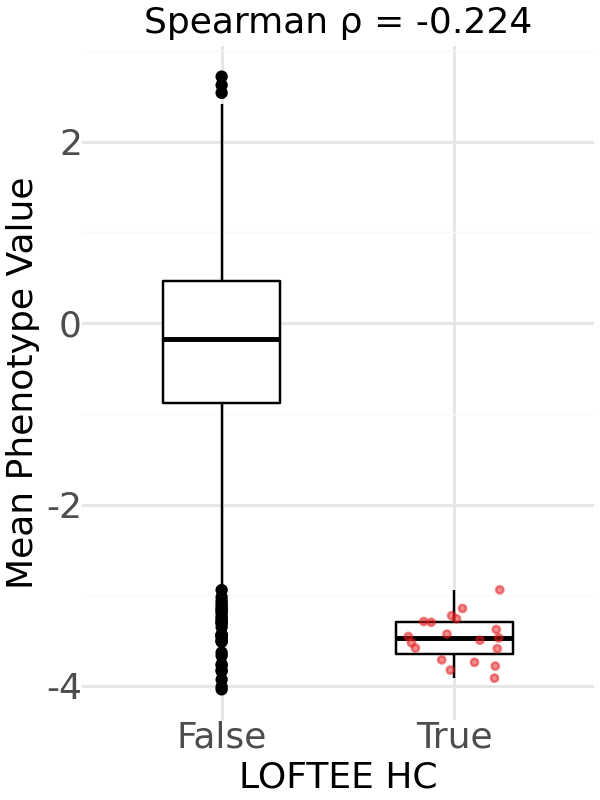

In [8]:
# LOFTEE HC box plot
loftee_anno = 'loftee_hc'
_loftee_row = anno_config_df.filter(pl.col('annotation') == loftee_anno)
loftee_color = _loftee_row['color'][0]
loftee_label = _loftee_row['label'][0]

box_df = (
    olink_plot_df
    .select(['id', loftee_anno, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        group = pl.when(pl.col(loftee_anno) == 1).then(pl.lit('True')).otherwise(pl.lit('False'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    box_df[loftee_anno].to_numpy(),
    box_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(box_df, aes(x='group', y='mean_pheno_value'))
    + geom_boxplot(color='black', width=0.5)
    + geom_jitter(aes(color='group', alpha='group'), width=0.2, size=1)
    + scale_color_manual(values={'False': 'black', 'True': loftee_color})
    + scale_alpha_manual(values={'False': 0, 'True': 0.5})
    + labs(
        x=loftee_label,
        y='Mean Phenotype Value',
        title=f'Spearman ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(3, 4),
        legend_position='none',
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
    )
)